In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_parquet("perm_visas_clean.parquet")

In [7]:
X2 = pd.get_dummies(
    df_model[['processing_days', 'log_employer_size', 'wage_10k', 'pw_level_9089',
              'job_info_education', 'decision_year']],
    columns=['pw_level_9089', 'job_info_education'],
    drop_first=True
).astype(float)
X2 = sm.add_constant(X2)
y2 = df_model['success']

audit_model = sm.OLS(y2, X2).fit(cov_type='HC3')
print(audit_model.summary())

                            OLS Regression Results                            
Dep. Variable:                success   R-squared:                       0.134
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     236.0
Date:                Tue, 18 Aug 2026   Prob (F-statistic):               0.00
Time:                        20:12:11   Log-Likelihood:                 43685.
No. Observations:               99596   AIC:                        -8.734e+04
Df Residuals:                   99583   BIC:                        -8.722e+04
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

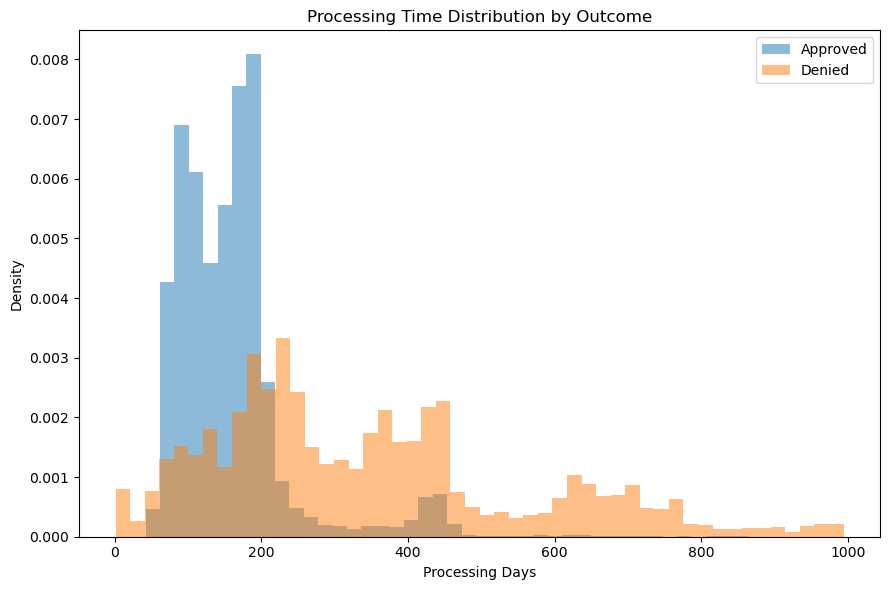

In [8]:
plt.figure(figsize=(9, 6))
df_model[df_model['success'] == 1]['processing_days'].plot(kind='hist', bins=50, alpha=0.5, label='Approved', density=True)
df_model[df_model['success'] == 0]['processing_days'].plot(kind='hist', bins=50, alpha=0.5, label='Denied', density=True)
plt.xlabel("Processing Days")
plt.ylabel("Density")
plt.title("Processing Time Distribution by Outcome")
plt.legend()
plt.tight_layout()
plt.show()